# SkillSync — Person 3: Fit Classification + Regression + Integration
**Datasets used:**
- `Resume.csv` — 2,484 resumes, 24 categories (for reference / merging with P1 & P2)
- `train.csv` / `test.csv` — resume–job description pairs with fit labels (No Fit / Potential Fit / Good Fit), from `cnamuangtoun/resume-job-description-fit` (HuggingFace)

**Note on ground truth:** the fit-label dataset's exact labeling methodology is not fully documented by its authors. This is disclosed as a limitation in the Dataset section of the paper, not hidden.


## Setup — Mount Drive & Load Data

In [6]:
import pandas as pd

# Core resume dataset
resume_df = pd.read_csv('/content/Resume.csv')
resume_df = resume_df[['ID', 'Resume_str', 'Category']]
print("Resume.csv:", resume_df.shape)

# Fit-labeled dataset
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')
print("train.csv:", train.shape, "| test.csv:", test.shape)

Resume.csv: (2484, 3)
train.csv: (6241, 3) | test.csv: (1759, 3)


In [7]:
print(train['label'].value_counts())
print()
print(test['label'].value_counts())
print()
print("Missing values:", train.isnull().sum().sum(), test.isnull().sum().sum())


label
No Fit           3143
Potential Fit    1556
Good Fit         1542
Name: count, dtype: int64

label
No Fit           857
Good Fit         458
Potential Fit    444
Name: count, dtype: int64

Missing values: 0 0


## Shared Evaluation Harness
Same functions Person 1 and Person 2 should import for consistent metrics across the team.


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, f1_score, accuracy_score

def get_split(X, y, stratify=None, test_size=0.2, seed=42):
    return train_test_split(X, y, test_size=test_size, stratify=stratify, random_state=seed)

def regression_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    return {"RMSE": round(rmse, 3), "MAE": round(mae, 3)}

def classification_metrics(y_true, y_pred):
    return {
        "Accuracy": round(accuracy_score(y_true, y_pred), 3),
        "Macro_F1": round(f1_score(y_true, y_pred, average="macro"), 3)
    }


In [9]:
harness_code = open('/dev/stdin').read() if False else None  # placeholder, real save below
harness_code = '''
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, f1_score, accuracy_score

def get_split(X, y, stratify=None, test_size=0.2, seed=42):
    return train_test_split(X, y, test_size=test_size, stratify=stratify, random_state=seed)

def regression_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    return {"RMSE": round(rmse, 3), "MAE": round(mae, 3)}

def classification_metrics(y_true, y_pred):
    return {
        "Accuracy": round(accuracy_score(y_true, y_pred), 3),
        "Macro_F1": round(f1_score(y_true, y_pred, average="macro"), 3)
    }
'''
with open('/content/eval_utils.py', 'w') as f:
    f.write(harness_code)

print("Saved eval_utils.py")

Saved eval_utils.py


## Part A — Fit Classification (Core Deliverable)
Train classical ML + Neural Network on real resume–JD fit labels.

In [10]:
train['combined_text'] = train['resume_text'] + " [SEP] " + train['job_description_text']
test['combined_text'] = test['resume_text'] + " [SEP] " + test['job_description_text']

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = tfidf.fit_transform(train['combined_text'])
X_test = tfidf.transform(test['combined_text'])

y_train, y_test = train['label'], test['label']
print(X_train.shape, X_test.shape)


(6241, 5000) (1759, 5000)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier

models = {
    "NaiveBayes": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='linear'),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
}

fit_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    fit_results[name] = classification_metrics(y_test, preds)
    print(name, fit_results[name])


NaiveBayes {'Accuracy': 0.496, 'Macro_F1': 0.391}
LogisticRegression {'Accuracy': 0.525, 'Macro_F1': 0.419}
SVM {'Accuracy': 0.527, 'Macro_F1': 0.43}
RandomForest {'Accuracy': 0.53, 'Macro_F1': 0.413}
MLP {'Accuracy': 0.548, 'Macro_F1': 0.483}


In [13]:
fit_results_df = pd.DataFrame(fit_results).T.sort_values('Macro_F1', ascending=False)
print(fit_results_df)

fit_results_df.to_csv('/content/fit_classification_results.csv', index=True)
print("Saved to /content/fit_classification_results.csv")

                    Accuracy  Macro_F1
MLP                    0.548     0.483
SVM                    0.527     0.430
LogisticRegression     0.525     0.419
RandomForest           0.530     0.413
NaiveBayes             0.496     0.391
Saved to /content/fit_classification_results.csv


## Confusion Matrix — Which Fit Levels Get Confused?

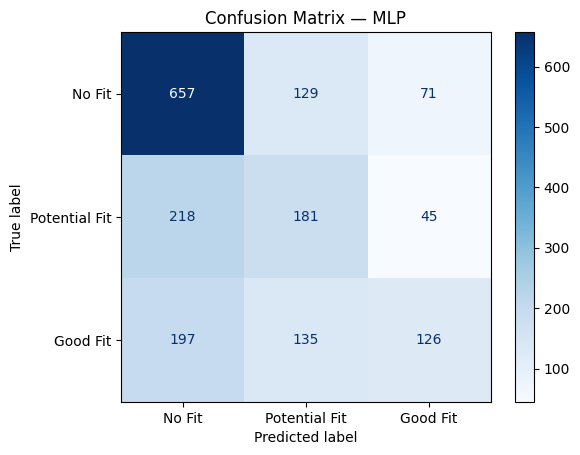

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model_name = fit_results_df.index[0]
best_model = models[best_model_name]
preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds,
                      labels=['No Fit','Potential Fit','Good Fit'])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Fit','Potential Fit','Good Fit']
)

disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')

# Save to Colab
plt.savefig('/content/fit_confusion_matrix.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

## Part B — Ordinal Regression (Optional Secondary Angle)
Treat fit as a numeric score (No Fit=0, Potential Fit=1, Good Fit=2) and test whether regression models can predict the continuous ordering.

In [17]:
import numpy as np

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return {"RMSE": round(rmse, 3), "MAE": round(mae, 3)}

reg_results = {}

for name, model in reg_models.items():
    model.fit(X_train, y_train_num)
    preds = model.predict(X_test)
    reg_results[name] = regression_metrics(y_test_num, preds)
    print(name, reg_results[name])

reg_results_df = pd.DataFrame(reg_results).T.sort_values("RMSE")
reg_results_df.to_csv("/content/fit_regression_results.csv", index=True)

print(reg_results_df)

LinearRegression {'RMSE': np.float64(0.934), 'MAE': 0.758}
RandomForestRegressor {'RMSE': np.float64(0.765), 'MAE': 0.65}
SVR {'RMSE': np.float64(0.781), 'MAE': 0.64}
MLPRegressor {'RMSE': np.float64(0.906), 'MAE': 0.676}
                        RMSE    MAE
RandomForestRegressor  0.765  0.650
SVR                    0.781  0.640
MLPRegressor           0.906  0.676
LinearRegression       0.934  0.758


## Consolidation — Merge with Person 1 & Person 2's Results
Run once they've exported their CSVs to the shared `data/` folder.

In [19]:
try:
    p1_results = pd.read_csv('/content/classification_results.csv', index_col=0)
    print("Person 1 (Category Classification):\n", p1_results)
except FileNotFoundError:
    print("Waiting on Person 1's classification_results.csv")

try:
    p2_results = pd.read_csv('/content/clustering_results.csv', index_col=0)
    print("\nPerson 2 (Quality Clustering):\n", p2_results)
except FileNotFoundError:
    print("Waiting on Person 2's clustering_results.csv")

print("\nPerson 3 (Fit Classification):\n", fit_results_df)
print("\nPerson 3 (Fit Regression):\n", reg_results_df)

Waiting on Person 1's classification_results.csv
Waiting on Person 2's clustering_results.csv

Person 3 (Fit Classification):
                     Accuracy  Macro_F1
MLP                    0.548     0.483
SVM                    0.527     0.430
LogisticRegression     0.525     0.419
RandomForest           0.530     0.413
NaiveBayes             0.496     0.391

Person 3 (Fit Regression):
                         RMSE    MAE
RandomForestRegressor  0.765  0.650
SVR                    0.781  0.640
MLPRegressor           0.906  0.676
LinearRegression       0.934  0.758


## Reference — Datasets & Links
| Purpose | Dataset | Link |
|---|---|---|
| Category classification + clustering | Resume.csv (Snehaan Bhawal, 2,484 resumes, 24 categories) | kaggle.com/datasets/snehaanbhawal/resume-dataset |
| Fit classification + regression (this notebook) | resume-job-description-fit | huggingface.co/datasets/cnamuangtoun/resume-job-description-fit |
| Related-work anchor | ResumeNet (Luo et al., 2018) | arxiv.org/pdf/1810.02832 |
| Literature search | Google Scholar | scholar.google.com |
